In [ ]:
# Estimating Okun's Law in the United Kingdom: A Simple Applied Econometrics
# Project in Python

# Import the required packages

import pandas as pd   # for data handling
import numpy as np    # for numerical calculations
import matplotlib.pyplot as plt    # for ploting
import statsmodels.api as sm       # for econometric estimation
from pandas_datareader import data as pdr    # download data from FRED

# also for plots (improves visualization)
plt.style.use("ggplot")

In [ ]:
# Defining the sample period

start = "1992-01-01"
end = "2025-12-31"

# Download UK GDP growth and unemployment data

gdp_growth = pdr.DataReader("NAEXKP02GBQ657S", "fred", start, end)
unemployment = pdr.DataReader("LRUN64TTGBQ156S", "fred", start, end)

In [ ]:
# Converting the unemployment series into a DataFrame
unemployment_df = unemployment.copy()

# Joining the two datasets using the date index
df = gdp_growth.join(
    unemployment_df,
    how="inner"
)

# Rename the columns
df.columns = [
    "gdp_growth",
    "unemployment"
]

# Display the first few observations
df.head()

,gdp_growth,unemployment
DATE,,
1992-01-01,-0.195532,9.781637
1992-04-01,1.825807,9.883054
1992-07-01,1.377539,10.034120
1992-10-01,0.452459,10.468790
1993-01-01,1.040926,10.725060


In [ ]:
# Creating the change in unemployment
df["du"] = df["unemployment"].diff()

# Removing missing values
df = df.dropna()

# Displaying the cleaned dataset
df.head()

,gdp_growth,unemployment,du
DATE,,,
1992-04-01,1.825807,9.883054,0.101417
1992-07-01,1.377539,10.034120,0.151066
1992-10-01,0.452459,10.468790,0.434670
1993-01-01,1.040926,10.725060,0.256270
1993-04-01,0.654097,10.477630,-0.247430


In [ ]:
# Summary statistics
df.describe()

,gdp_growth,unemployment,du
count,135.000000,135.000000,135.000000
mean,0.560057,6.141605,-0.033058
std,2.954758,1.829143,0.237291
min,-23.217672,3.789416,-0.533555
25%,0.109258,4.771120,-0.175300
50%,0.648590,5.409236,-0.067560
75%,1.038397,7.900794,0.077761
max,19.797767,10.725060,0.887394


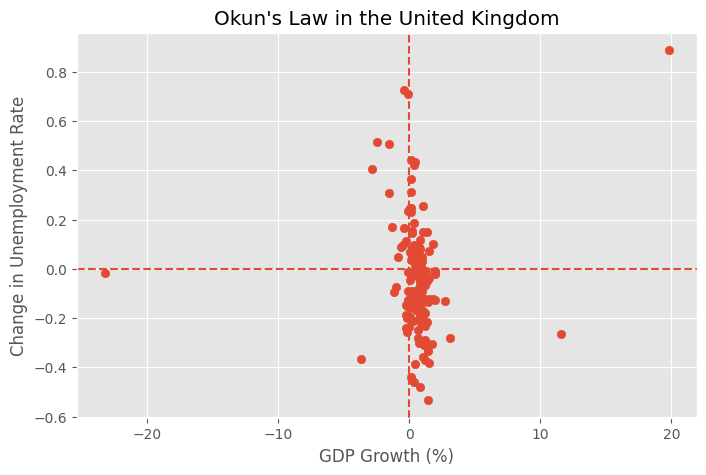

In [ ]:
# Scatterplot: GDP growth vs change in unemployment

plt.figure(figsize=(8, 5))

plt.scatter(
    df["gdp_growth"],
    df["du"]
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("GDP Growth (%)")
plt.ylabel("Change in Unemployment Rate")
plt.title("Okun's Law in the United Kingdom")

plt.show()

In [ ]:
# Independent variable
X = df["gdp_growth"]

# Constant/intercept
X = sm.add_constant(X)

# Dependent variable
y = df["du"]

# Estimating the OLS model
model = sm.OLS(y, X)
results = model.fit()

# Display the regression results
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                     du   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.4082
Date:                Tue, 16 Jun 2026   Prob (F-statistic):              0.524
Time:                        11:10:58   Log-Likelihood:                 3.3452
No. Observations:                 135   AIC:                            -2.690
Df Residuals:                     133   BIC:                             3.120
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0355      0.021     -1.706      0.0

In [ ]:
# Estimate the model with HAC/Newey-West robust standard errors

results_hac = model.fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 4}
)

print(results_hac.summary())

                            OLS Regression Results                            
Dep. Variable:                     du   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.1630
Date:                Tue, 16 Jun 2026   Prob (F-statistic):              0.687
Time:                        11:12:23   Log-Likelihood:                 3.3452
No. Observations:                 135   AIC:                            -2.690
Df Residuals:                     133   BIC:                             3.120
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0355      0.032     -1.108      0.2

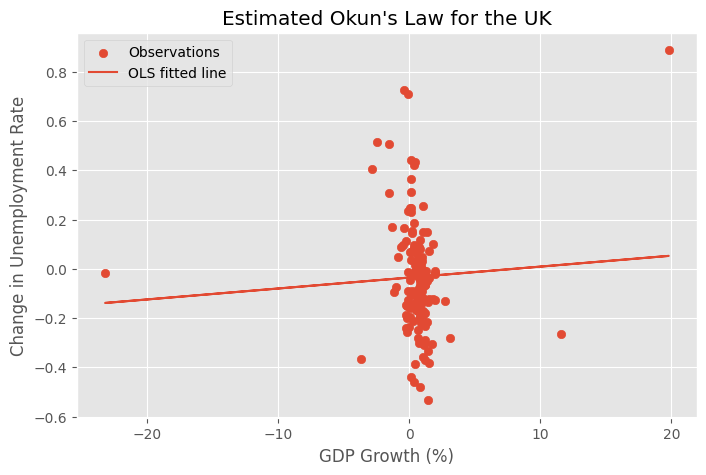

In [ ]:
# Scatterplot with fitted regression line

plt.figure(figsize=(8, 5))

plt.scatter(
    df["gdp_growth"],
    df["du"],
    label="Observations"
)

plt.plot(
    df["gdp_growth"],
    results.predict(X),
    label="OLS fitted line"
)

plt.xlabel("GDP Growth (%)")
plt.ylabel("Change in Unemployment Rate")
plt.title("Estimated Okun's Law for the UK")
plt.legend()

plt.show()

In [ ]:
# Import SQLite
import sqlite3

# Create an in-memory SQLite database
conn = sqlite3.connect(":memory:")

# Save the Okun dataset into SQL
df.to_sql(
    "okun_table",
    conn,
    index=True,
    if_exists="replace"
)

print("Database created successfully.")
print("Table 'okun_table' loaded into SQLite.")

Database created successfully.
Table 'okun_table' loaded into SQLite.


In [ ]:
# Query the Okun table using SQL

query = """
SELECT
    DATE,
    gdp_growth,
    unemployment,
    du
FROM okun_table
WHERE gdp_growth < 0
ORDER BY DATE
"""

recession_periods = pd.read_sql_query(query, conn)

display(recession_periods.head())

,DATE,gdp_growth,unemployment,du
0,1994-04-01 00:00:00,-0.043580,9.805758,-0.234912
1,1998-10-01 00:00:00,-0.118102,6.202702,-0.088994
2,2006-01-01 00:00:00,-0.496173,5.294529,0.098592
3,2007-10-01 00:00:00,-0.163217,5.239702,-0.149973
4,2008-04-01 00:00:00,-1.300065,5.427594,0.171142


In [ ]:
# Average change in unemployment when GDP growth is positive or negative

query = """
SELECT
    CASE
        WHEN gdp_growth >= 0 THEN 'Positive GDP growth'
        ELSE 'Negative GDP growth'
    END AS Growth_State,
    AVG(du) AS Avg_Change_Unemployment
FROM okun_table
GROUP BY Growth_State
"""

growth_summary = pd.read_sql_query(query, conn)

display(growth_summary)

,Growth_State,Avg_Change_Unemployment
0,Negative GDP growth,0.070170
1,Positive GDP growth,-0.058866


In [ ]:
# Extract the Okun coefficient

beta = results_hac.params["gdp_growth"]
p_value = results_hac.pvalues["gdp_growth"]

print(f"Estimated Okun coefficient: {beta:.3f}")
print(f"P-value: {p_value:.3f}")

if beta < 0:
    print("The coefficient is negative, which is consistent with Okun's Law.")
else:
    print("The coefficient is not negative, which is not consistent with the standard Okun's Law.")

Estimated Okun coefficient: 0.004
P-value: 0.686
The coefficient is not negative, which is not consistent with the standard Okun's Law.


In [ ]:
# Model with lagged values of gdp and unemployment

# Create lagged variables
df["gdp_growth_lag1"] = df["gdp_growth"].shift(1)
df["du_lag1"] = df["du"].shift(1)

# Remove missing observations
df = df.dropna()

# Define explanatory variables
X = df[[
    "gdp_growth",
    "gdp_growth_lag1",
    "du_lag1"
]]

# Add constant
X = sm.add_constant(X)

# Dependent variable
y = df["du"]

# Estimate the model
model = sm.OLS(y, X)
results = model.fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 4}
)

# Display results
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                     du   R-squared:                       0.328
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     14.16
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           4.86e-08
Time:                        11:24:12   Log-Likelihood:                 29.362
No. Observations:                 134   AIC:                            -50.72
Df Residuals:                     130   BIC:                            -39.13
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0078      0.020     

In [ ]:
# Compute the total short-run effect
okun_effect = (
    results.params["gdp_growth"]
    + results.params["gdp_growth_lag1"]
)

print(f"Total estimated Okun effect: {okun_effect:.3f}")

Total estimated Okun effect: -0.014
